In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

original_data = pd.read_csv('./dataset1.csv')
data = original_data.copy()  # making a copy so we don't modify the original dataset
data.head()

,start_time,bat_landing_to_food,habit,rat_period_start,rat_period_end,seconds_after_rat_arrival,risk,reward,month,sunset_time,hours_after_sunset,season
0,30/12/2017 18:37,16.000000,rat,30/12/2017 18:35,30/12/2017 18:38,108,1,0,0,30/12/2017 16:45,1.870833,0
1,30/12/2017 19:51,0.074016,fast,30/12/2017 19:50,30/12/2017 19:55,17,0,1,0,30/12/2017 16:45,3.100833,0
2,30/12/2017 19:51,4.000000,fast,30/12/2017 19:50,30/12/2017 19:55,41,0,1,0,30/12/2017 16:45,3.107500,0
3,30/12/2017 19:52,10.000000,rat,30/12/2017 19:50,30/12/2017 19:55,111,1,0,0,30/12/2017 16:45,3.126944,0
4,30/12/2017 19:54,15.000000,rat,30/12/2017 19:50,30/12/2017 19:55,194,1,0,0,30/12/2017 16:45,3.150000,0


# Understanding Data

In [ ]:
data.info()  # Getting the information about given DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   start_time                 907 non-null    object 
 1   bat_landing_to_food        907 non-null    float64
 2   habit                      866 non-null    object 
 3   rat_period_start           907 non-null    object 
 4   rat_period_end             907 non-null    object 
 5   seconds_after_rat_arrival  907 non-null    int64  
 6   risk                       907 non-null    int64  
 7   reward                     907 non-null    int64  
 8   month                      907 non-null    int64  
 9   sunset_time                907 non-null    object 
 10  hours_after_sunset         907 non-null    float64
 11  season                     907 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 85.2+ KB


In [ ]:
data.isnull().sum()  # checking the null value present in each column

start_time                    0
bat_landing_to_food           0
habit                        41
rat_period_start              0
rat_period_end                0
seconds_after_rat_arrival     0
risk                          0
reward                        0
month                         0
sunset_time                   0
hours_after_sunset            0
season                        0
dtype: int64

### Creating new Date column
We have notice few columns contains data in `{date time}` format. So, we decided to create a new column name `Date` which holds dtype date associated to those column and original column contains 
only time. 

In [ ]:
cols = ['start_time', 'rat_period_start', 'rat_period_end', 'sunset_time'] #colmns that contain data in {date time} format.
def split_datetime_column(data, cols): 
    for col in cols: # looping through each columns
        data[col] = pd.to_datetime(data[col], dayfirst=True, errors='coerce') # converting data in each row of the column to dtype time, removing date
        data[f'Date'] = data[col].dt.date  # assigning 1 Date column and assiging date
        
        data[col] = data[col].dt.time      # assigning time to each row
    return data

new_data_with_date = split_datetime_column(data, cols)

In [9]:
new_data_with_date.head()

,start_time,bat_landing_to_food,habit,rat_period_start,rat_period_end,seconds_after_rat_arrival,risk,reward,month,sunset_time,hours_after_sunset,season,Date
0,18:37:00,16.000000,rat,18:35:00,18:38:00,108,1,0,0,16:45:00,1.870833,0,2017-12-30
1,19:51:00,0.074016,fast,19:50:00,19:55:00,17,0,1,0,16:45:00,3.100833,0,2017-12-30
2,19:51:00,4.000000,fast,19:50:00,19:55:00,41,0,1,0,16:45:00,3.107500,0,2017-12-30
3,19:52:00,10.000000,rat,19:50:00,19:55:00,111,1,0,0,16:45:00,3.126944,0,2017-12-30
4,19:54:00,15.000000,rat,19:50:00,19:55:00,194,1,0,0,16:45:00,3.150000,0,2017-12-30


### Visualizing

TypeError: unhashable type: 'Series'

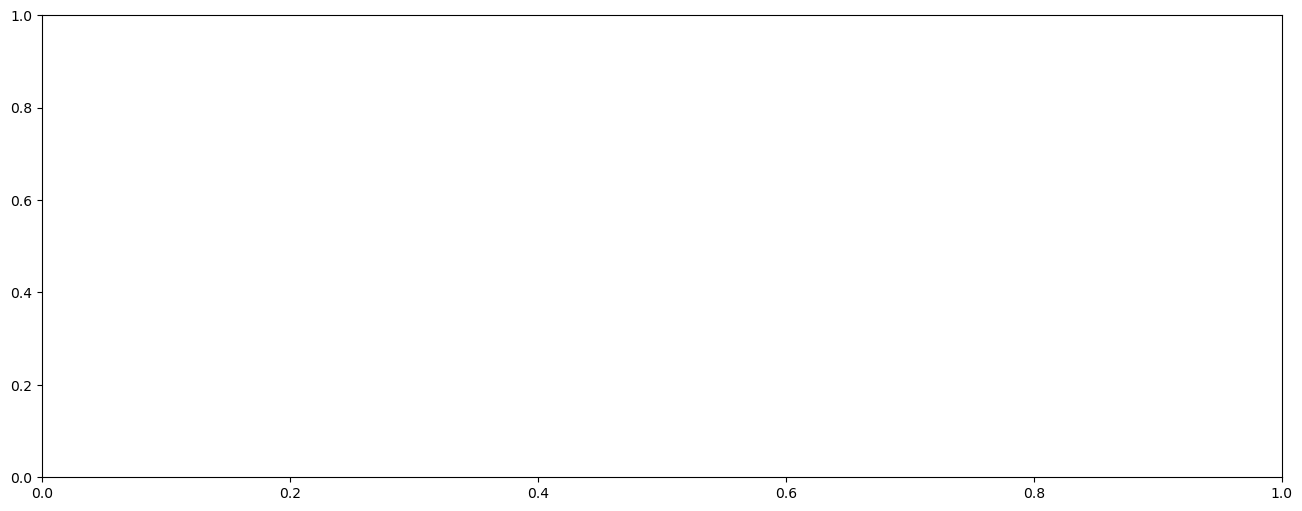

In [18]:
# Grouping Data by Date
gbd_data = new_data_with_date.groupby('Date');

plt.figure(figsize=(16,6))
sns.lineplot(x=gbd_data['Date'], y=gbd_data['seconds_after_rat_arrival'], label='start time')
plt.xlabel('Time bat landed on food platform')